# IMPORT AND SETUP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
np.random.seed(42)

# DATA PREPARATION

In [3]:
df = pd.read_csv('churn_modeling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# How many rows and columns are there in the dataset?

In [5]:
df.shape

(10000, 14)

In [6]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [7]:
# Check for missing values

In [8]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
# There are no missing values

In [10]:
print('Duplicates are', df.duplicated().sum())

Duplicates are 0


In [11]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
print(f"""- The dataset has 10000 records of clients having relationship with the bank 
- The average credit score is 650, with values ranging from 350 to 850. The age variable has a broad band
- Some of them have 0 in the account balance, whereas the maximum is at 250898
- The average estimated salary is 100090. Our target variable that we're going to predict is the churn probability that customer will leave the bank, whose average is 20.37% 
- Around 70.5% and 51.51% have respectively a credit card and are active members""")

- The dataset has 10000 records of clients having relationship with the bank 
- The average credit score is 650, with values ranging from 350 to 850. The age variable has a broad band
- Some of them have 0 in the account balance, whereas the maximum is at 250898
- The average estimated salary is 100090. Our target variable that we're going to predict is the churn probability that customer will leave the bank, whose average is 20.37% 
- Around 70.5% and 51.51% have respectively a credit card and are active members


In [13]:
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [14]:
print('Median:', df['CreditScore'].median())
print('Mode:', df['CreditScore'].mode()[0])
print('Var:', df['CreditScore'].var().round(1))
print('Skewness:', df['CreditScore'].skew().round(2))
print('Kurtosis:', df['CreditScore'].kurt().round(2))
print('IQR:', df["CreditScore"].quantile(0.75) - df["CreditScore"].quantile(0.25))

Median: 652.0
Mode: 850
Var: 9341.9
Skewness: -0.07
Kurtosis: -0.43
IQR: 134.0


In [15]:
print(f"""- The central value of the distribution is at 652. The most frequent value is 850, meaning most customers have the maximum credit score
- The skewness is close negative to zero, which means approximately symmetric with a slight concentration of data points to the right
- The variance shows a very high spread between the smallest and the highest number
- Same happens to kurtosis, indicating a slightly flatter distribution than a normal distribution""")

- The central value of the distribution is at 652. The most frequent value is 850, meaning most customers have the maximum credit score
- The skewness is close negative to zero, which means approximately symmetric with a slight concentration of data points to the right
- The variance shows a very high spread between the smallest and the highest number
- Same happens to kurtosis, indicating a slightly flatter distribution than a normal distribution


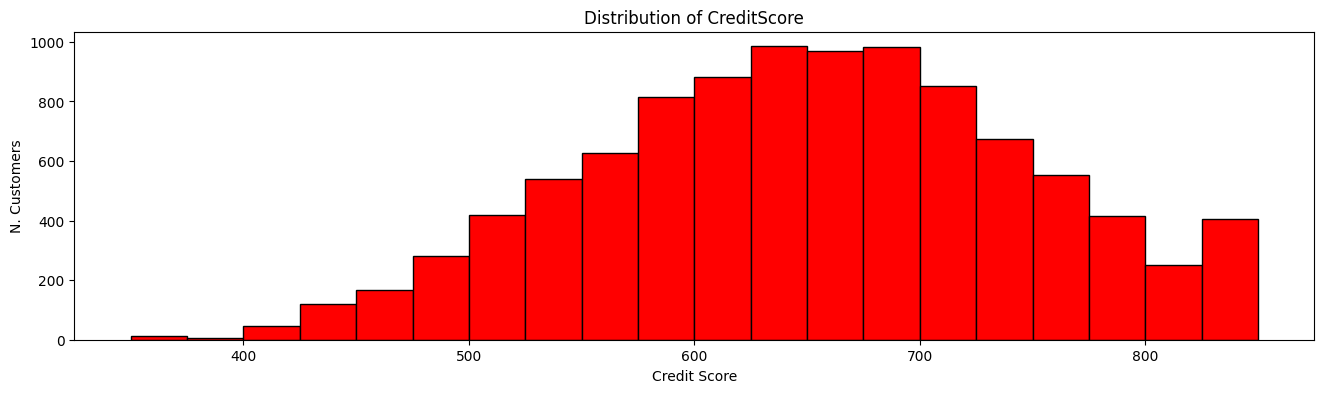

In [16]:
plt.figure(figsize=(16,4))

plt.hist(df['CreditScore'], bins = 20, color = 'red', edgecolor = 'black')
plt.title('Distribution of CreditScore')
plt.xlabel('Credit Score')
plt.ylabel('N. Customers')

plt.show()

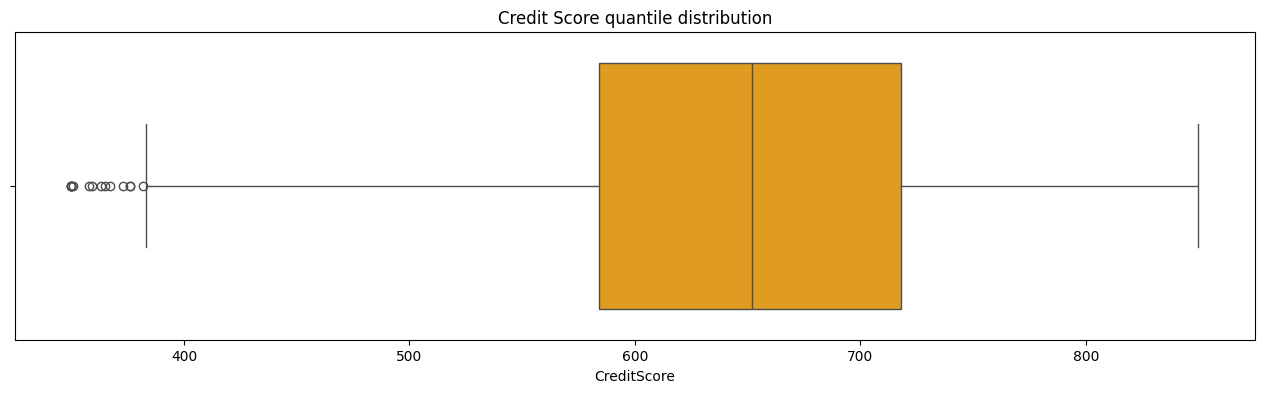

In [17]:
plt.figure(figsize=(16,4))

sns.boxplot(x=df['CreditScore'], color='orange')
plt.title('Credit Score quantile distribution')

plt.show()

In [18]:
print(f"""- The median credit score is approximately 650. The middle 50% of customers have a credit score between 580 and 720
- Lower side outliers are visible, representing a small percentage 
- Since credit scores are concentrated around upper-side range, the bank serves mostly financially stable customers
- Are customers with low credit score more likely to leave the bank?""")

- The median credit score is approximately 650. The middle 50% of customers have a credit score between 580 and 720
- Lower side outliers are visible, representing a small percentage 
- Since credit scores are concentrated around upper-side range, the bank serves mostly financially stable customers
- Are customers with low credit score more likely to leave the bank?


In [19]:
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

In [20]:
print('Median:', df['Age'].median())
print('Mode:', df['Age'].mode()[0])
print('Var:', df['Age'].var().round(1))
print('Skewness:', df['Age'].skew().round(2))
print('Kurtosis:', df['Age'].kurt().round(2))
print('IQR:', df["Age"].quantile(0.75) - df["Age"].quantile(0.25))

Median: 37.0
Mode: 37
Var: 110.0
Skewness: 1.01
Kurtosis: 1.4
IQR: 12.0


In [21]:
print(f"""- The central value is 37 years, which coincides with most frequent value
- The skewness is equal to 1, indicating a concentration of data points to the left 
- The variance isn't high but shows a moderate spread between data points
- The kurtosis is 1.5 but less than 3, indicating a flat top and thin tails""")

- The central value is 37 years, which coincides with most frequent value
- The skewness is equal to 1, indicating a concentration of data points to the left 
- The variance isn't high but shows a moderate spread between data points
- The kurtosis is 1.5 but less than 3, indicating a flat top and thin tails


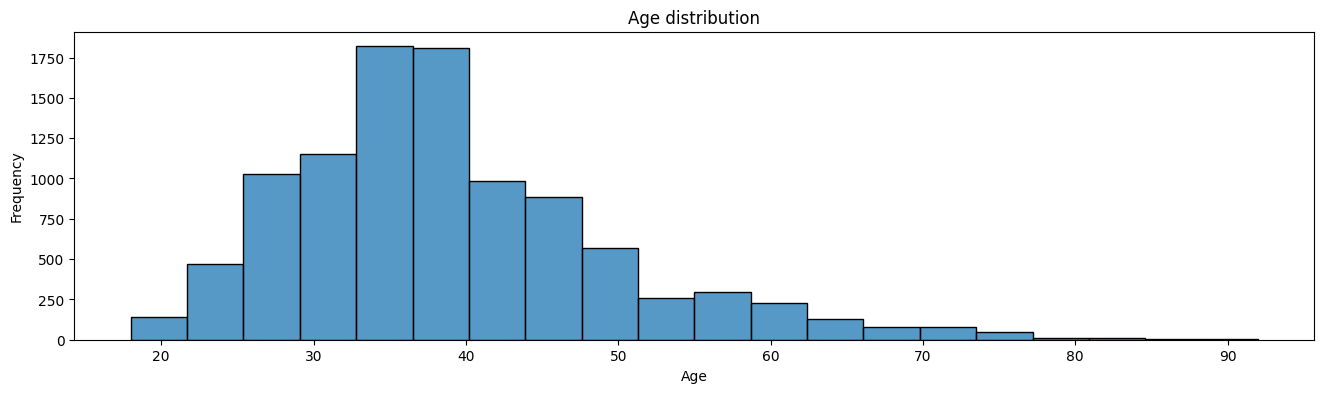

In [22]:
plt.figure(figsize=(16,4))

sns.histplot(df['Age'], bins = 20, cbar = 'lightblue')
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

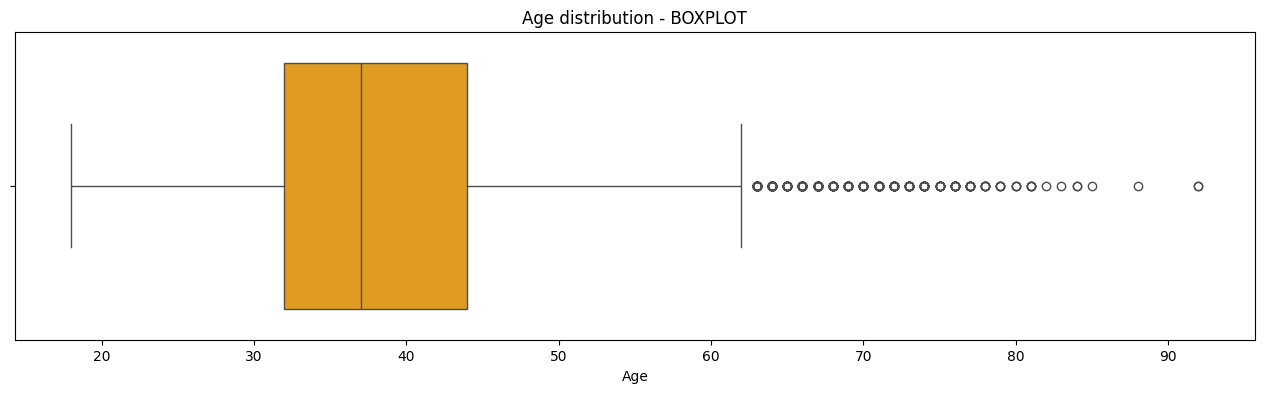

In [23]:
plt.figure(figsize=(16,4))

sns.boxplot(x=df['Age'], color='orange')
plt.title('Age distribution - BOXPLOT')

plt.show()

In [24]:
print(f"""- The majority of customers are 32-44 years old, so the banking clients are approximately middle-aged, neither too young nor too old 
- Higher-side outliers are visible, meaning the clients from 64 years old to afterwards aren't concentrated in the central band of data points
- Why does the bank decide to not serve elder customers? Are they more likely to leave the bank?""")

- The majority of customers are 32-44 years old, so the banking clients are approximately middle-aged, neither too young nor too old 
- Higher-side outliers are visible, meaning the clients from 64 years old to afterwards aren't concentrated in the central band of data points
- Why does the bank decide to not serve elder customers? Are they more likely to leave the bank?


In [25]:
df['Balance'].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

In [26]:
print('Median:', df['Balance'].median().round(1))
print('Mode:', df['Balance'].mode()[0])
print('Var:', df['Balance'].var().round(1))
print('Skewness:', df['Balance'].skew().round(2))
print('Kurtosis:', df['Balance'].kurt().round(2))
print('IQR:', df["Balance"].quantile(0.75) - df["Balance"].quantile(0.25))

Median: 97198.5
Mode: 0.0
Var: 3893436176.0
Skewness: -0.14
Kurtosis: -1.49
IQR: 127644.24


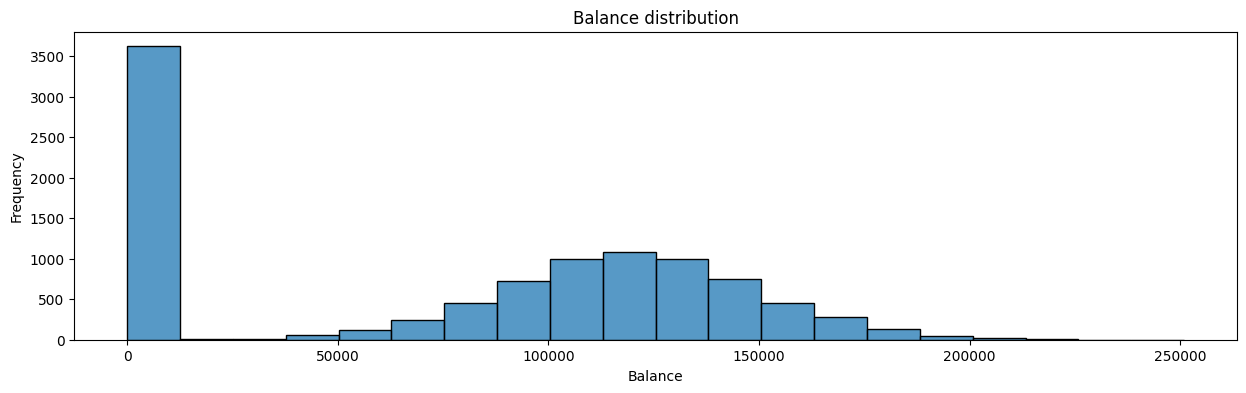

In [27]:
plt.figure(figsize=(15,4))

sns.histplot(df['Balance'], bins = 20, cbar = 'lightblue')
plt.title('Balance distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')

plt.show()

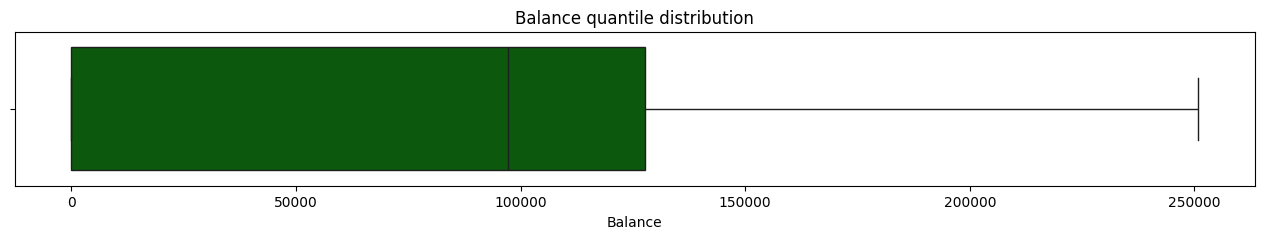

In [28]:
plt.figure(figsize=(16,2))

sns.boxplot(x=df['Balance'], color='darkgreen')
plt.title('Balance quantile distribution')

plt.show()

In [29]:
print(f"""- Despite the large spike of many customers at zero account balance, the distribution is approximately bell-shaped with a massive spread between data points
- Customers with zero balances may require targeted marketing campaigns or account activation strategies""")

- Despite the large spike of many customers at zero account balance, the distribution is approximately bell-shaped with a massive spread between data points
- Customers with zero balances may require targeted marketing campaigns or account activation strategies


In [30]:
pd.crosstab(
    df['Balance'] == 0,  
    df['Exited'],
    normalize='index'
).round(3)*100

Exited,0,1
Balance,,
False,75.9,24.1
True,86.2,13.8


## OBSERVATION

In [31]:
print(f"""- False row represents those customers that don't have a zero account balance
- True row represents those customers that do have a zero account balance
- 0 column represents those customers that are more likely to stay with the bank
- 1 column represents those customers that are more likely to leave the bank and that's what most interest us 
- Customers with no zero account balance have a churn rate of 24.1% and are more likely to leave than customers with zero balances 
- So, they're more likely to switch to competitors offering better interest rates, investment opportunities or premium banking services 
- The bank should focus on retaining high-value customers by improving loyalty programs, personalized offers and customer service
""")

- False row represents those customers that don't have a zero account balance
- True row represents those customers that do have a zero account balance
- 0 column represents those customers that are more likely to stay with the bank
- 1 column represents those customers that are more likely to leave the bank and that's what most interest us 
- Customers with no zero account balance have a churn rate of 24.1% and are more likely to leave than customers with zero balances 
- So, they're more likely to switch to competitors offering better interest rates, investment opportunities or premium banking services 
- The bank should focus on retaining high-value customers by improving loyalty programs, personalized offers and customer service



In [32]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

pd.crosstab(
    df["AgeGroup"],
    df["Exited"],
    normalize="index"
).round(3) * 100

Exited,0,1
AgeGroup,,
18-30,92.5,7.5
31-40,87.9,12.1
41-50,66.0,34.0
51-60,43.8,56.2
60+,75.2,24.8


In [33]:
print(f"""- The 51-60 age group has the highest churn rate (56%) and more likely to leave the bank than younger customers
- It should be prioritized in customer retention strategies by offering tailored products or loyalty rewards""")

- The 51-60 age group has the highest churn rate (56%) and more likely to leave the bank than younger customers
- It should be prioritized in customer retention strategies by offering tailored products or loyalty rewards


In [34]:
pd.crosstab(
    df["Geography"],
    df["Exited"],
    normalize="index"
).round(3) * 100

Exited,0,1
Geography,,
France,83.8,16.2
Germany,67.6,32.4
Spain,83.3,16.7


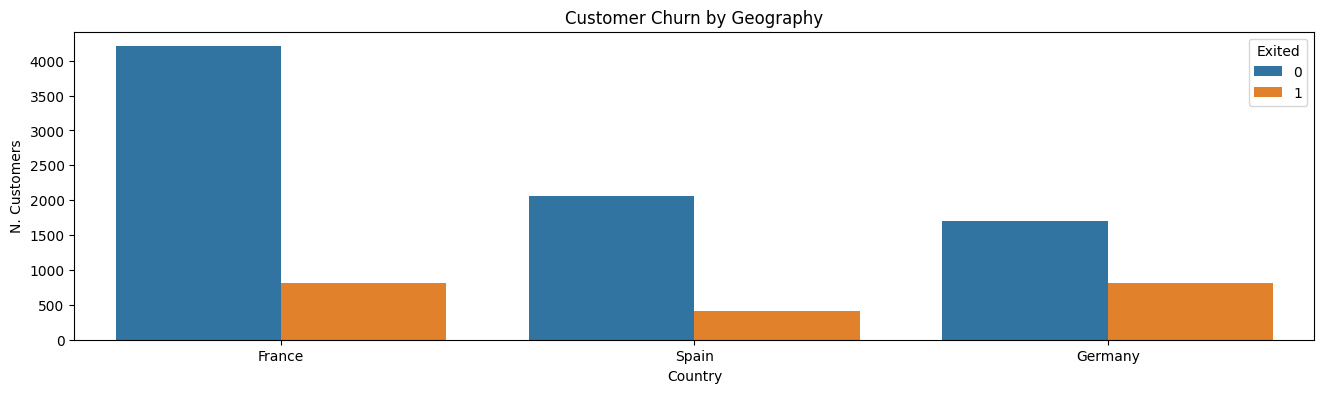

In [35]:
plt.figure(figsize=(16,4))

sns.countplot(x="Geography", hue="Exited", data=df)

plt.title("Customer Churn by Geography")
plt.xlabel("Country")
plt.ylabel("N. Customers")

plt.legend(title="Exited")

plt.show()

In [36]:
print(f"""- German clients of 51-60 age segment are likely to churn 
- Customer service issues or customer service dissatisfaction might be two of main possible reasons
""")

- German clients of 51-60 age segment are likely to churn 
- Customer service issues or customer service dissatisfaction might be two of main possible reasons



In [37]:
pd.crosstab(
    df["IsActiveMember"],
    df["Exited"],
    normalize="index"
).round(3) * 100

Exited,0,1
IsActiveMember,,
0,73.1,26.9
1,85.7,14.3


In [38]:
print(f"""- No active members are more likely to leave. Will this result be confirmed when predicting the target variable on new test data?
""")

- No active members are more likely to leave. Will this result be confirmed when predicting the target variable on new test data?



In [39]:
pd.crosstab(
    df["Gender"],
    df["Exited"],
    normalize="index"
).round(3) * 100

Exited,0,1
Gender,,
Female,74.9,25.1
Male,83.5,16.5


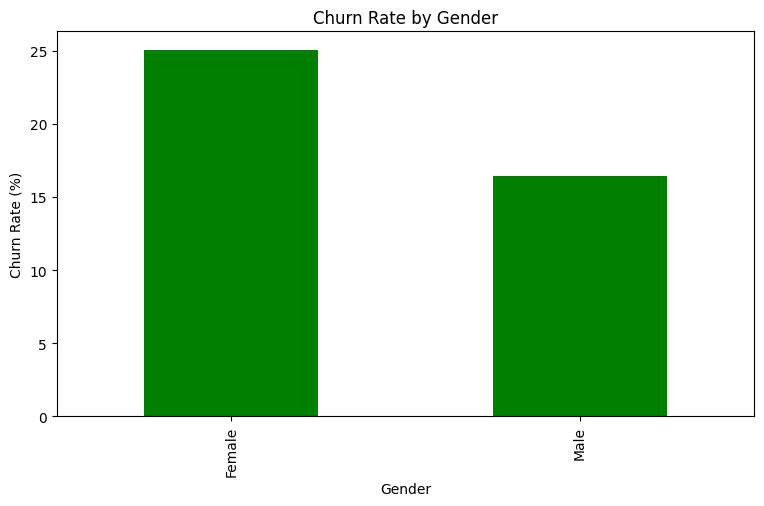

In [40]:
churn_rate = (
    pd.crosstab(df["Gender"], df["Exited"], normalize="index") * 100
)

plt.figure(figsize=(9,5))
churn_rate[1].plot(kind="bar", color = 'green')

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

In [41]:
print(f"""- Female customers have higher probability to churn than male ones due to the high spread difference
- Product gender differences and service expectations may contribute to this gap
- In order to reduce it, the bank should conduct feedback surveys targeting specifically female customers and design tailored solutions for retention
""")

- Female customers have higher probability to churn than male ones due to the high spread difference
- Product gender differences and service expectations may contribute to this gap
- In order to reduce it, the bank should conduct feedback surveys targeting specifically female customers and design tailored solutions for retention



In [42]:
pd.crosstab(
    df["NumOfProducts"],
    df["Exited"],
    normalize="index"
).round(3) * 100

Exited,0,1
NumOfProducts,,
1,72.3,27.7
2,92.4,7.6
3,17.3,82.7
4,0.0,100.0


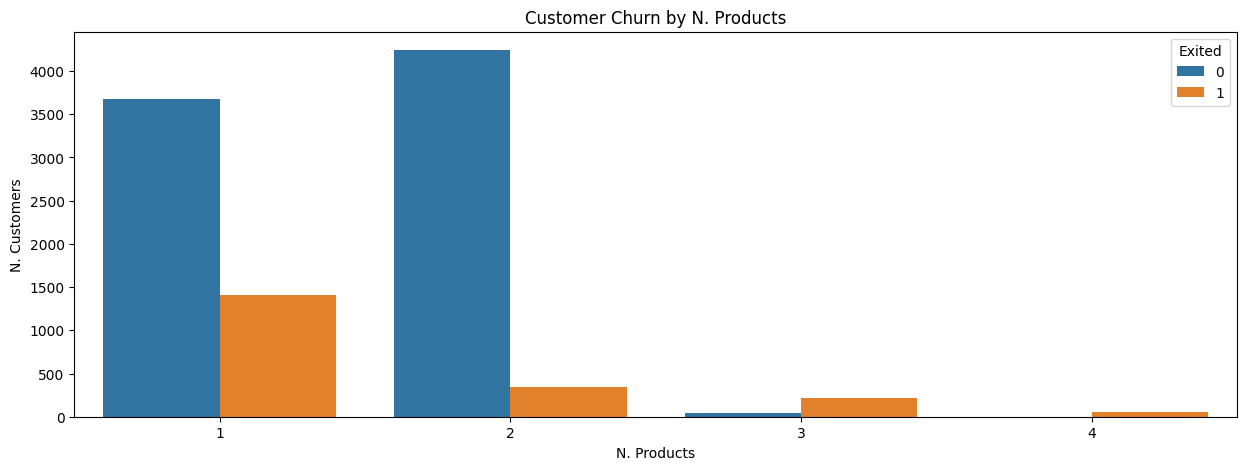

In [43]:
plt.figure(figsize=(15,5))

sns.countplot(x="NumOfProducts", hue="Exited", data=df)

plt.title("Customer Churn by N. Products")
plt.xlabel("N. Products")
plt.ylabel("N. Customers")

plt.legend(title="Exited")

plt.show()

In [44]:
print(f"""- Customers with 4 products have the highest churn rate but the sample size is too small and should be interpreted with caution
- Based on 266 customers, these have a very high churn rate at 82.71%. Whereas customers with two banking products appear to be the most loyal segment
- Possible recomendations might be to encourage customers with one product to adopt a second banking product, as customers with two products have the lowest churn rate
- Assist customers with 3 to 4 products by talking to high-experienced financial consultants to better manage their money
""")

- Customers with 4 products have the highest churn rate but the sample size is too small and should be interpreted with caution
- Based on 266 customers, these have a very high churn rate at 82.71%. Whereas customers with two banking products appear to be the most loyal segment
- Possible recomendations might be to encourage customers with one product to adopt a second banking product, as customers with two products have the lowest churn rate
- Assist customers with 3 to 4 products by talking to high-experienced financial consultants to better manage their money



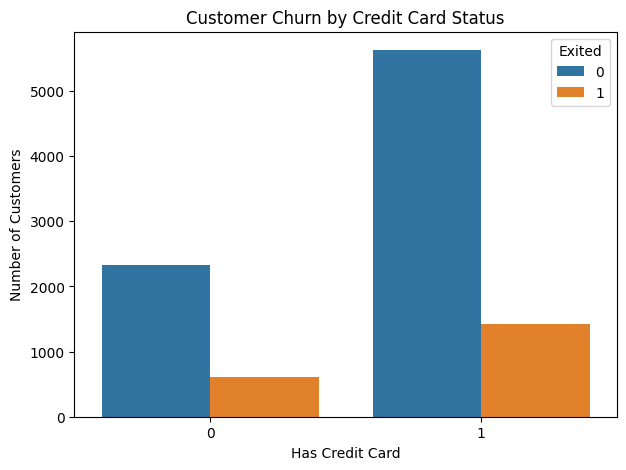

In [45]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="HasCrCard",
    hue="Exited",
    data=df
)

plt.title("Customer Churn by Credit Card Status")
plt.xlabel("Has Credit Card")
plt.ylabel("Number of Customers")

plt.legend(title="Exited")

plt.show()

In [46]:
pd.crosstab(
    df["HasCrCard"],
    df["Exited"],
    normalize="index"
).round(3) * 100

Exited,0,1
HasCrCard,,
0,79.2,20.8
1,79.8,20.2


In [47]:
print(f"""- A client owning a credit card or not isn't a strong predictor to be considered as one of the variables for considering a possible bank churning
- The difference is only 0.6 percentage points
- Instead, considering age, geography, balance, estimated salary, number of products, tenure and isactivemember as key decision variable in logistic regression model
""")

- A client owning a credit card or not isn't a strong predictor to be considered as one of the variables for considering a possible bank churning
- The difference is only 0.6 percentage points
- Instead, considering age, geography, balance, estimated salary, number of products, tenure and isactivemember as key decision variable in logistic regression model



<Axes: >

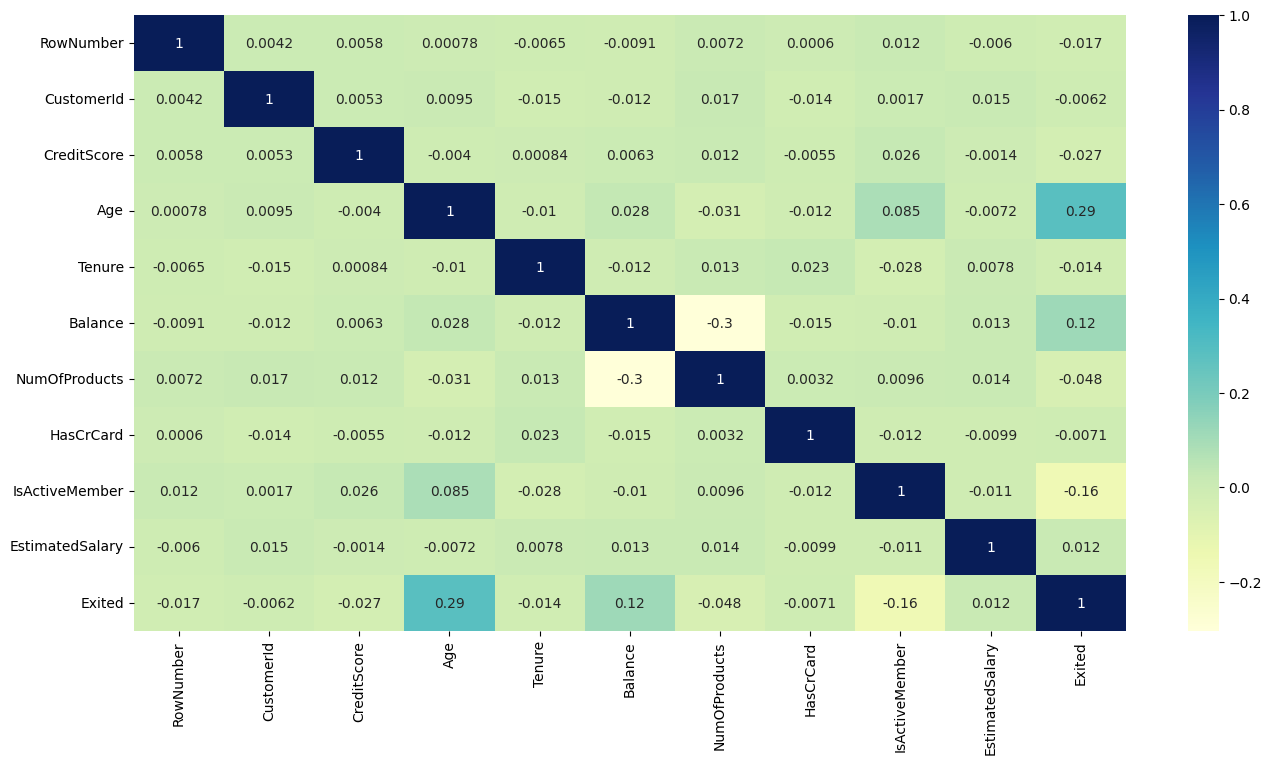

In [48]:
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = 'YlGnBu')

# DATA PREPROCESSING

In [49]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns = ['Geography'], drop_first = True)

In [50]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,41-50,False,False
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,41-50,False,True
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,41-50,False,False
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,31-40,False,False
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,41-50,False,True


# FEATURES SELECTION

In [51]:
features = ['Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
X = df[features]
y = df['Exited']

# SPLIT DATA INTO TRAIN AND TEST SET

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# FEATURE SCALING

In [53]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

# LOGISTIC REGRESSION

In [54]:
# BUILD AND TRAIN THE LOGISTIC REGRESSION MODEL
log_reg = LogisticRegression(random_state = 42)
log_reg.fit(X_train, y_train)

# MAKE PREDICTIONS
y_pred_log_reg = log_reg.predict(X_test)

# EVALUATE THE MODEL
conf_matrix = confusion_matrix(y_test, y_pred_log_reg)
classification_report = classification_report(y_test, y_pred_log_reg)
accuracy_score = accuracy_score(y_test, y_pred_log_reg)

print(conf_matrix, classification_report, accuracy_score)

[[1540   67]
 [ 312   81]]               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.21      0.30       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000
 0.8105


# PREDICTIONS ON NEW UNSEEN DATA

In [55]:
num_columns = X_train.shape[1]
new_customer = [np.random.choice(X_train[:, i]) for i in range(num_columns)]

new_data = pd.DataFrame([new_customer])

print("=== NEW CUSTOMER OBSERVATION ===")

df_vis = new_data.T.rename(columns={0: 'Values'})
df_vis.index = [f"Feature {i}" for i in range(num_columns)]
print(df_vis) 
print("-" * 50)

probability_new_data = log_reg.predict_proba(new_data.values)
prob_churn = probability_new_data[0][1]

print(f"Prediction result for this new client:")
print(f"-> Churn Probability: {prob_churn:.2%}")

=== NEW CUSTOMER OBSERVATION ===
             Values
Feature 0  0.913248
Feature 1 -0.370569
Feature 2 -1.389442
Feature 3 -1.218471
Feature 4 -0.916688
Feature 5 -1.025834
Feature 6  0.316730
Feature 7 -0.579467
Feature 8 -0.576388
--------------------------------------------------
Prediction result for this new client:
-> Churn Probability: 13.02%
